


#Résolution d'Équations Différentielles par Réseaux de Neurones
Ce notebook présente une implémentation de Physics-Informed Neural Networks (PINNs) pour résoudre une équation différentielle de type Poisson. L'objectif est d'apprendre une fonction qui satisfait à la fois une équation physique (PDE) et des conditions aux limites (BC), sans avoir besoin d'un jeu de données de solutions pré-calculées.

# 1.Importations et Configuration.
Nous utilisons PyTorch pour la construction du modèle et la différenciation automatique, ainsi que la bibliothèque torch.func (anciennement functorch) pour le calcul efficace des gradients et la vectorisation via vmap.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import grad, vmap
import matplotlib.pyplot as plt
import numpy as np

#2. Définition du Problème Physique
Nous définissons ici la source $f(x)$ de notre équation de Poisson $\frac{d^2u}{dx^2} = f(x)$, ainsi que la solution analytique exacte pour pouvoir valider la précision de notre modèle à la fin de l'entraînement.

In [ ]:
def f(x):
  return torch.sin(2*torch.pi*x)

In [ ]:
def solution(x):
  return -f(x)/(4*(torch.pi**2))

In [ ]:
def activation_fct(x):
  return torch.tanh(x)

#3. Architecture du Modèle et Opérateurs Différentiels
Nous définissons une classe snn (Simple Neural Network) avec une seule couche cachée.La fonction f_forward permet d'appeler le modèle de manière fonctionnelle (nécessaire pour torch.func). Nous définissons ensuite les opérateurs de dérivée première (f_forward_x) et seconde (f_forward_xx) par rapport à l'entrée $x$ en utilisant la différenciation automatique.

In [ ]:
class snn(nn.Module):
  def __init__(self,n_neurons):
    super().__init__()
    self.couche=nn.Linear(1,n_neurons)
    self.out=nn.Linear(n_neurons,1)

  def forward(self,x):
    x=activation_fct(self.couche(x))
    x=self.out(x)
    return x




def f_forward(x,net,params,buffers):
  return torch.func.functional_call(net, (params,buffers) ,x.unsqueeze(-1)).squeeze()

f_forward_x = grad(f_forward, argnums=0)
f_forward_xx = grad(f_forward_x, argnums=0)


#4. Boucle d'Entraînement de base
La fonction optimal_snn entraîne le réseau en minimisant une fonction de perte composée de deux termes :Perte PDE : L'écart entre la dérivée seconde du réseau et la fonction cible $f(x)$ sur une grille de points.Perte BC : Le respect des conditions aux limites aux points $x=0$ et $x=1$.

In [ ]:
def optimal_snn(net,silent=False):

  epochs=1000
  N=1000
  losses=np.zeros(epochs)

  optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
  params = dict(net.named_parameters())
  buffers = dict(net.named_buffers())
  grid=torch.linspace(0,1,N)
  solution_grid=vmap(solution,in_dims=(0,))(grid)
  f_grid=vmap(f, in_dims=(0,))(grid)
  for i in range(epochs):
    loss=0
    f_forward_xx_grid=vmap(f_forward_xx, in_dims=(0, None,None, None))(grid,net,params,buffers)

    bc_0 = torch.tensor(0.0)
    bc_1 = torch.tensor(1.0)

    loss+=((f_forward_xx_grid-f_grid)**2).mean()
    loss+=f_forward(bc_0,net,params,buffers)**2
    loss+=f_forward(bc_1,net,params,buffers)**2
    losses[i]=loss.item()

    if i%100==0:
       print(f"Epoch {i}, Loss: {loss.item()}")
       if not silent:
          plt.plot(grid, solution_grid.detach(), label='real solution')
          f_forward_grid=vmap(f_forward, in_dims=(0,None, None, None))(grid,net,params,buffers)
          plt.plot(grid, f_forward_grid.detach(), label='optimal snn')

          plt.legend()
          plt.show()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  plt.plot(np.log(losses))
  plt.xlabel("Epoch")
  plt.ylabel("Log(Loss)")
  plt.title("Evolution du logarithme de la Perte")
  plt.show()





# Exécution du premier test
Initialisation du réseau avec 3 neurones et lancement de l'optimisation.

Epoch 0, Loss: 0.6422477960586548


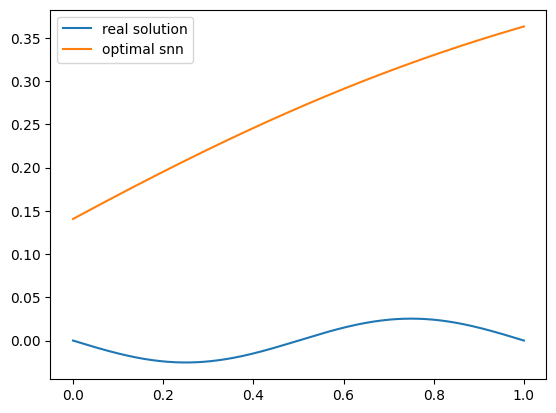

Epoch 100, Loss: 0.1630108654499054


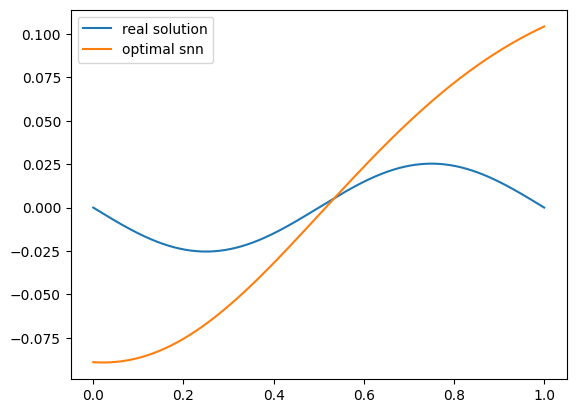

Epoch 200, Loss: 0.013451985083520412


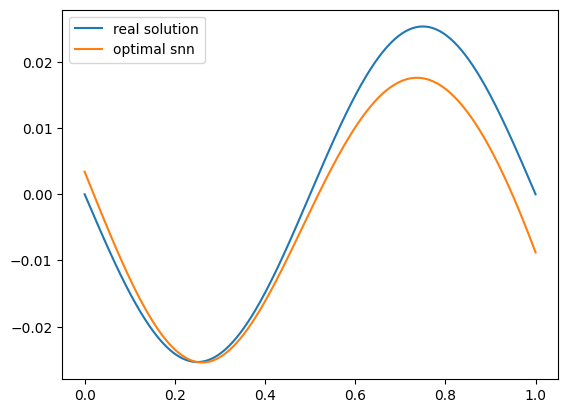

Epoch 300, Loss: 0.008719943463802338


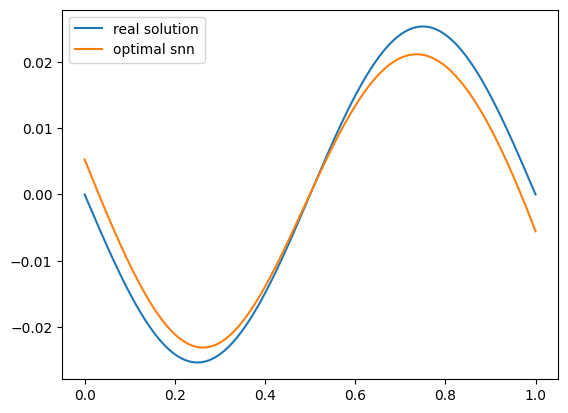

Epoch 400, Loss: 0.006694799289107323


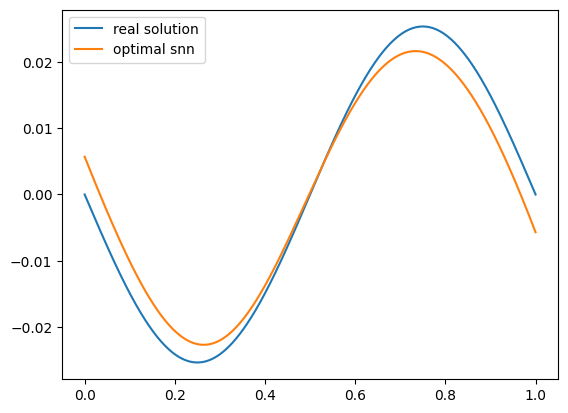

Epoch 500, Loss: 0.005563290789723396


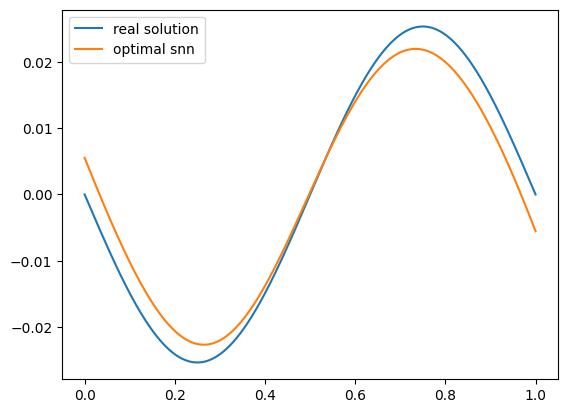

Epoch 600, Loss: 0.004819134715944529


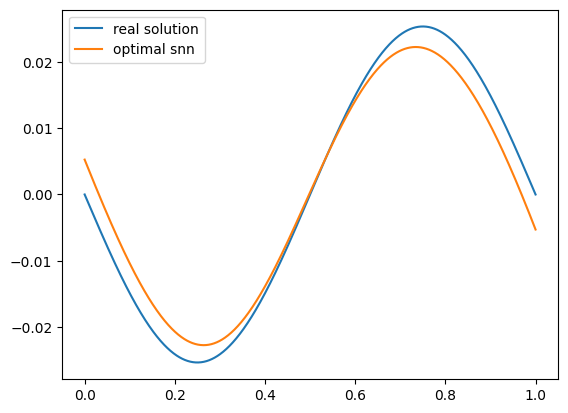

Epoch 700, Loss: 0.004250078462064266


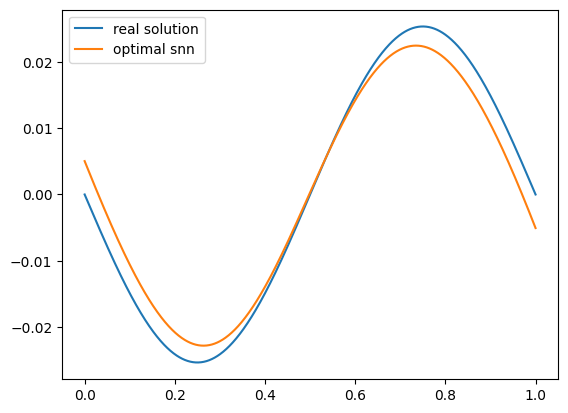

Epoch 800, Loss: 0.0037775319069623947


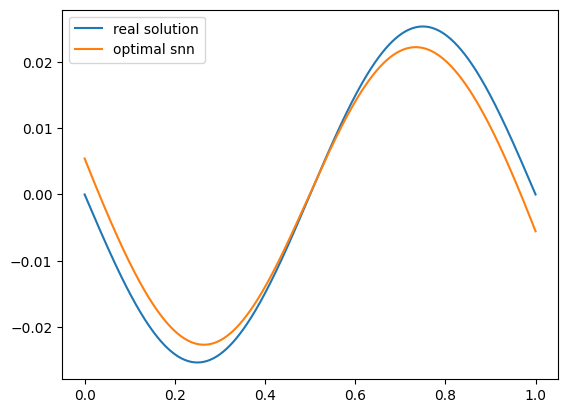

Epoch 900, Loss: 0.0037425453774631023


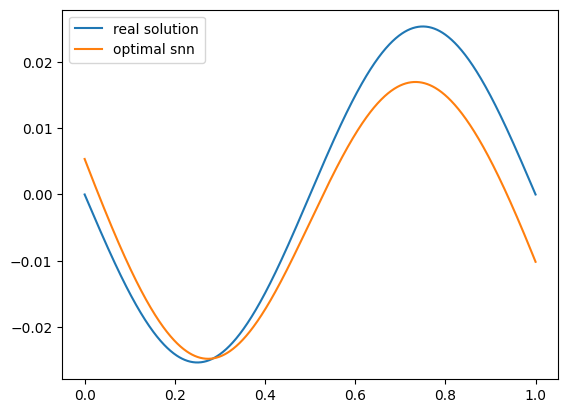

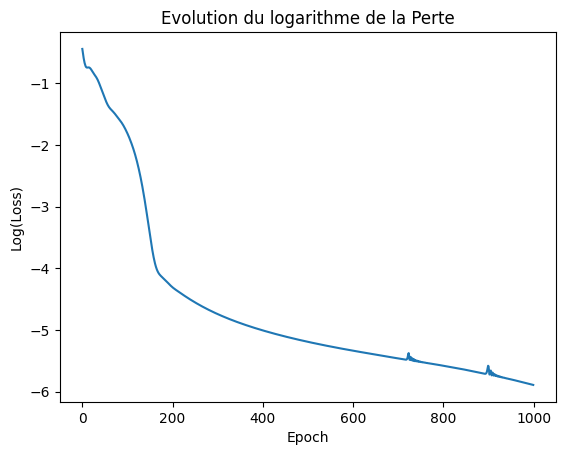

In [ ]:
net=snn(3)
optimal_snn(net,silent=False)

#6. Optimisation des Hyperparamètres
Dans cette section, nous créons une version plus flexible du modèle (snn_optimized) permettant de tester différentes fonctions d'activation et nombres de neurones. Nous intégrons également un ensemble de validation et la sauvegarde des meilleurs paramètres pour éviter le sur-apprentissage.

In [ ]:
import torch
import torch.nn as nn
from torch.func import grad, vmap
import matplotlib.pyplot as plt

def f(x):
  return torch.sin(2*torch.pi*x)

def solution(x):
  return -f(x)/(4*(torch.pi**2))

activation_functions_map = {
    'tanh': torch.tanh,
    'relu': torch.relu,
    'sigmoid': torch.sigmoid
}


class snn_optimized(nn.Module):
  def __init__(self, n_neurons, activation_name='tanh'):
    super().__init__()
    self.couche = nn.Linear(1, n_neurons)
    self.activation = activation_functions_map[activation_name]
    self.out = nn.Linear(n_neurons, 1)

  def forward(self, x):
    x = self.activation(self.couche(x))
    x = self.out(x)
    return x


def f_forward_optimized(x, net: snn_optimized, params, buffers):
  return torch.func.functional_call(net, (params, buffers), x.unsqueeze(-1)).squeeze()

f_forward_x_optimized = grad(f_forward_optimized, argnums=0)
f_forward_xx_optimized = grad(f_forward_x_optimized, argnums=0)


def optimal_snn_optimized(net, activation_name: str, Ntrain=1000, Nval=1000, epochs=1000, silent=False):
  optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
  params = dict(net.named_parameters())
  buffers = dict(net.named_buffers())

  grid_train = torch.linspace(0, 1, Ntrain).unsqueeze(-1)
  grid_val = torch.linspace(0, 1, Nval).unsqueeze(-1)
  f_grid_train = vmap(f, in_dims=(0,))(grid_train.squeeze(-1))
  f_grid_val = vmap(f, in_dims=(0,))(grid_val.squeeze(-1))
  min_val_loss = float('inf')
  best_params = None
  best_buffers = None
  params = dict(net.named_parameters())
  buffers = dict(net.named_buffers())

  for i in range(epochs):
    f_forward_xx_train = vmap(f_forward_xx_optimized, in_dims=(0, None, None, None))(grid_train.squeeze(-1), net, params, buffers)
    bc_0 = torch.tensor(0.0)
    bc_1 = torch.tensor(1.0)

    train_loss_pde = ((f_forward_xx_train - f_grid_train)**2).mean()
    train_loss_bc = f_forward_optimized(bc_0, net, params, buffers)**2 + \
                    f_forward_optimized(bc_1, net, params, buffers)**2
    train_loss = train_loss_pde + train_loss_bc

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()


    with torch.no_grad():
        f_forward_xx_val = vmap(f_forward_xx_optimized, in_dims=(0, None, None, None))(grid_val.squeeze(-1), net, params, buffers)
        val_loss_pde = ((f_forward_xx_val - f_grid_val)**2).mean()
        val_loss_bc = f_forward_optimized(bc_0, net, params, buffers)**2 + \
                      f_forward_optimized(bc_1, net, params, buffers)**2
        val_loss = val_loss_pde + val_loss_bc

        if val_loss.item() < min_val_loss:
            min_val_loss = val_loss.item()
            best_params = {k: v.clone() for k, v in params.items()}
            best_buffers = {k: v.clone() for k, v in buffers.items()}

    if i % 100 == 0 and not silent:
      print(f"Epoch {i}, Train Loss: {train_loss.item():.4e}, Val Loss: {val_loss.item():.4e}")

  # Calculate L2 norm for the best model (based on validation loss)
  if best_params is not None and best_buffers is not None:
      solution_grid_best_model = vmap(solution, in_dims=(0,))(grid_train.squeeze(-1))
      f_forward_grid_best_model = vmap(f_forward_optimized, in_dims=(0, None, None, None))(
          grid_train.squeeze(-1), net, best_params, best_buffers
      )
      l2_norm = torch.sqrt(torch.mean((solution_grid_best_model - f_forward_grid_best_model)**2)).item()
  else:
      # If no improvement, use the last trained model
      solution_grid_current_model = vmap(solution, in_dims=(0,))(grid_train.squeeze(-1))
      f_forward_grid_current_model = vmap(f_forward_optimized, in_dims=(0, None, None, None))(
          grid_train.squeeze(-1), net, params, buffers
      )
      l2_norm = torch.sqrt(torch.mean((solution_grid_current_model - f_forward_grid_current_model)**2)).item()

  if not silent:
    plot_params = best_params if best_params is not None else params
    plot_buffers = best_buffers if best_buffers is not None else buffers
    solution_grid = vmap(solution, in_dims=(0,))(grid_train.squeeze(-1))
    plt.plot(grid_train.squeeze(-1), solution_grid, label='solution réelle')
    f_forward_grid = vmap(f_forward_optimized, in_dims=(0, None, None, None))(grid_train.squeeze(-1), net, plot_params, plot_buffers)
    plt.plot(grid_train.squeeze(-1), f_forward_grid.detach(), label='snn optimal')
    plt.legend()
    plt.title(f"Activation: {activation_name}, Neurones: {net.couche.out_features}, Min Val Loss: {min_val_loss:.4e}, L2 Norm: {l2_norm:.4e}")
    plt.show()

  return min_val_loss, best_params, best_buffers, l2_norm

#7. Recherche de la meilleure configuration
Nous itérons sur plusieurs fonctions d'activation (tanh, relu, sigmoid) et différentes tailles de couches pour trouver le modèle qui minimise l'erreur de validation. Enfin, nous testons ce modèle sur un ensemble de test de 10 000 points.

In [ ]:
#Cette fonction trace un heap map en lui donnant une matrice,
import seaborn as sns
import matplotlib.colors as colors
activation_functions = ['tanh', 'relu', 'sigmoid']
n_neurons_list = [5, 10, 20, 50]
def draw_mat(mat,label_r="",label_c="",title=""):
    plt.figure(figsize=(len(n_neurons_list), len(activation_functions)))
    sns.heatmap(mat, annot=True, fmt=".2e", cmap="viridis", xticklabels=n_neurons_list, yticklabels=activation_functions,norm=colors.LogNorm(),square=True,linewidths=0.1)
    plt.xlabel(label_c)
    plt.ylabel(label_r)
    plt.title(title)
    plt.show()




Entraînement avec Activation: tanh, Neurones: 5
  Val Loss: 1.3875e-04, L2 Norm: 3.7292e-04

Entraînement avec Activation: tanh, Neurones: 10
  Val Loss: 6.9374e-05, L2 Norm: 2.5840e-04

Entraînement avec Activation: tanh, Neurones: 20
  Val Loss: 1.7103e-04, L2 Norm: 2.8654e-04

Entraînement avec Activation: tanh, Neurones: 50
  Val Loss: 1.7766e-05, L2 Norm: 1.4927e-04

Entraînement avec Activation: relu, Neurones: 5
  Val Loss: 4.9950e-01, L2 Norm: 1.6420e-02

Entraînement avec Activation: relu, Neurones: 10
  Val Loss: 4.9950e-01, L2 Norm: 3.5228e-02

Entraînement avec Activation: relu, Neurones: 20
  Val Loss: 4.9950e-01, L2 Norm: 1.8470e-02

Entraînement avec Activation: relu, Neurones: 50
  Val Loss: 4.9950e-01, L2 Norm: 1.6844e-02

Entraînement avec Activation: sigmoid, Neurones: 5
  Val Loss: 4.4489e-03, L2 Norm: 2.0715e-03

Entraînement avec Activation: sigmoid, Neurones: 10
  Val Loss: 8.2382e-04, L2 Norm: 1.0005e-03

Entraînement avec Activation: sigmoid, Neurones: 20
  Va

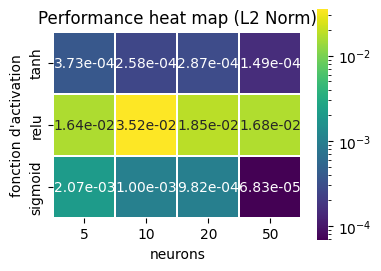

Perte sur l'Ensemble de Test pour le Meilleur Modèle (Validation Loss): 2.4606e-05
L2 Norm sur l'Ensemble de Test pour le Meilleur Modèle: 6.8320e-05


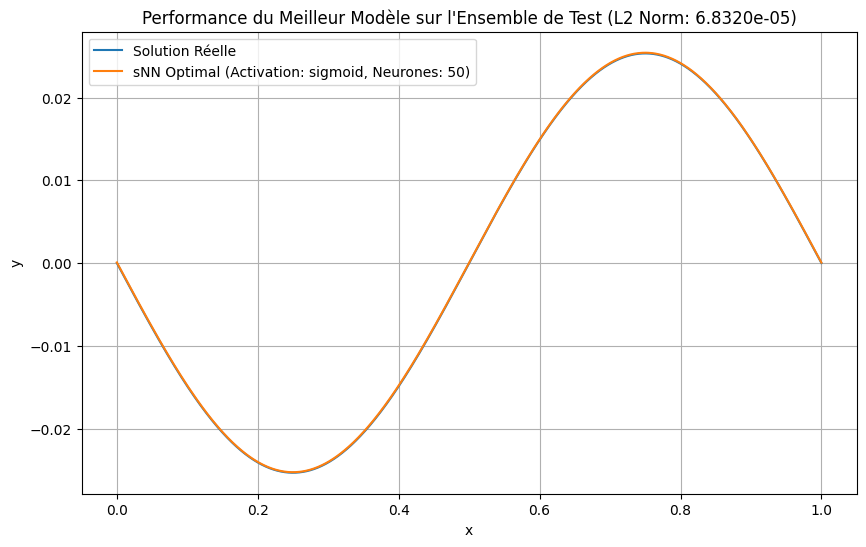

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors

def draw_mat(mat,label_r="",label_c="",title=""):
    plt.figure(figsize=(len(n_neurons_list), len(activation_functions)))
    sns.heatmap(mat, annot=True, fmt=".2e", cmap="viridis", xticklabels=n_neurons_list, yticklabels=activation_functions,norm=colors.LogNorm(),square=True,linewidths=0.1)
    plt.xlabel(label_c)
    plt.ylabel(label_r)
    plt.title(title)
    plt.show()

activation_functions = ['tanh', 'relu', 'sigmoid']
n_neurons_list = [5, 10, 20, 50]

N_TRAIN = 1000
N_VAL = 1000
N_TEST = 10000
EPOCHS = 1000

best_l2_norm = float('inf') # Changed from best_val_loss
best_hyperparams = {}
best_model_params = None
best_model_buffers = None

mat=torch.zeros(len(activation_functions),len(n_neurons_list))

for act_name in activation_functions:
    for n_neurons in n_neurons_list:
        print(f"\nEntraînement avec Activation: {act_name}, Neurones: {n_neurons}")
        current_net = snn_optimized(n_neurons, activation_name=act_name)
        val_loss, trained_params, trained_buffers, l2_norm_result = optimal_snn_optimized(
            current_net,
            activation_name=act_name,
            Ntrain=N_TRAIN,
            Nval=N_VAL,
            epochs=EPOCHS,
            silent=True
        )
        mat[activation_functions.index(act_name),n_neurons_list.index(n_neurons)]=l2_norm_result # Storing L2 norm

        print(f"  Val Loss: {val_loss:.4e}, L2 Norm: {l2_norm_result:.4e}") # Updated print

        if l2_norm_result < best_l2_norm: # Comparing L2 norm for best model
            best_l2_norm = l2_norm_result
            best_hyperparams = {
                'activation': act_name,
                'neurons': n_neurons
            }
            best_model_params = trained_params
            best_model_buffers = trained_buffers

print(f"Meilleurs Hyperparamètres (basé sur L2 Norm): {best_hyperparams}")
print(f"Meilleure L2 Norm: {best_l2_norm:.4e}")

draw_mat(mat,"fonction d'activation","neurons","Performance heat map (L2 Norm)") # Updated title


final_net = snn_optimized(best_hyperparams['neurons'], activation_name=best_hyperparams['activation'])

test_grid = torch.linspace(0, 1, N_TEST).unsqueeze(-1)
solution_grid_test = vmap(solution, in_dims=(0,))(test_grid.squeeze(-1))
f_grid_test = vmap(f, in_dims=(0,))(test_grid.squeeze(-1))

with torch.no_grad():
    f_forward_xx_test = vmap(f_forward_xx_optimized, in_dims=(0, None, None, None))(
        test_grid.squeeze(-1), final_net, best_model_params, best_model_buffers
    )
    bc_0 = torch.tensor(0.0)
    bc_1 = torch.tensor(1.0)
    test_loss_pde = ((f_forward_xx_test - f_grid_test)**2).mean()
    test_loss_bc = f_forward_optimized(bc_0, final_net, best_model_params, best_model_buffers)**2 + \
                   f_forward_optimized(bc_1, final_net, best_model_params, best_model_buffers)**2
    test_loss = test_loss_pde + test_loss_bc

    # Calculate L2 norm on the test set for the best model
    f_forward_grid_test = vmap(f_forward_optimized, in_dims=(0, None, None, None))(
        test_grid.squeeze(-1), final_net, best_model_params, best_model_buffers
    )
    l2_norm_test = torch.sqrt(torch.mean((solution_grid_test - f_forward_grid_test)**2)).item()

print(f"Perte sur l'Ensemble de Test pour le Meilleur Modèle (Validation Loss): {test_loss.item():.4e}")
print(f"L2 Norm sur l'Ensemble de Test pour le Meilleur Modèle: {l2_norm_test:.4e}")


plt.figure(figsize=(10, 6))
plt.plot(test_grid.squeeze(-1), solution_grid_test, label='Solution Réelle')
plt.plot(test_grid.squeeze(-1), f_forward_grid_test.detach(), label=f"sNN Optimal (Activation: {best_hyperparams['activation']}, Neurones: {best_hyperparams['neurons']})")
plt.legend()
plt.title(f"Performance du Meilleur Modèle sur l'Ensemble de Test (L2 Norm: {l2_norm_test:.4e})")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

#8. Modèle Multi-couches (Deep Neural Network)
Nous définissons une architecture NN capable de gérer un nombre variable de couches cachées (n_couches), permettant d'explorer des réseaux plus profonds.

In [ ]:
class NN(nn.Module):
  def __init__(self, n_neurons,n_couches, activation_name='tanh'):
    super().__init__()
    self.couches=nn.ModuleList()
    self.couches.append(nn.Linear(1,n_neurons))
    self.activation=activation_functions_map[activation_name]
    for i in range(n_couches):
      self.couches.append(nn.Linear(n_neurons,n_neurons))
    self.couches.append(nn.Linear(n_neurons,1))

  def forward(self,x):
    x=self.couches[0](x)
    for i in range(1,len(self.couches)):
      x=self.activation(x)
      x=self.couches[i](x)
    return x

#Etude de la précision en fct du nombre de couches


Démarrage de l'optimisation du nombre des couches...

Entraînement avec 3 couches cachées
  Perte de Validation: 1.1647e-04

Entraînement avec 5 couches cachées
  Perte de Validation: 3.2379e-04

Entraînement avec 7 couches cachées
  Perte de Validation: 7.3684e-05

Entraînement avec 10 couches cachées
  Perte de Validation: 3.8147e-05

Entraînement avec 13 couches cachées
  Perte de Validation: 1.0193e-05

Entraînement avec 17 couches cachées
  Perte de Validation: 4.6191e-04

Entraînement avec 20 couches cachées
  Perte de Validation: 8.8236e-05

Entraînement avec 25 couches cachées
  Perte de Validation: 4.7293e-01

Entraînement avec 30 couches cachées
  Perte de Validation: 4.9950e-01

Entraînement avec 35 couches cachées
  Perte de Validation: 4.9950e-01


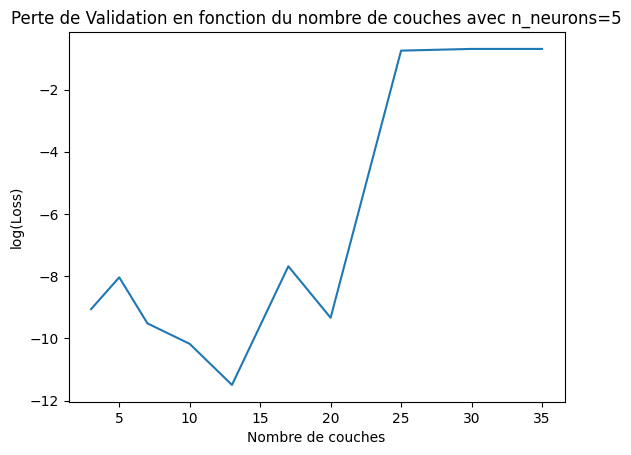

In [ ]:
n_couches_list=[3,5,7,10,13,17,20,25,30,35]
n_neurons=5
N_TRAIN = 1000
N_VAL = 1000
N_TEST = 10000
EPOCHS = 1000
Losses=np.zeros(len(n_couches_list))
print("Démarrage de l'optimisation du nombre des couches...")
i=0
for n_couches in n_couches_list:
  print(f"\nEntraînement avec {n_couches} couches cachées")
  current_net=NN(n_neurons,n_couches)
  min_val,best_params,best_buffers=optimal_snn_optimized(current_net,activation_name='tanh',Ntrain=N_TRAIN,Nval=N_VAL,epochs=EPOCHS,silent=True)
  Losses[i]=min_val
  i+=1
  print(f"  Perte de Validation: {min_val:.4e}")
plt.plot(n_couches_list, np.log(Losses))
plt.xlabel("Nombre de couches")
plt.ylabel("log(Loss)")
plt.title("Perte de Validation en fonction du nombre de couches avec n_neurons=5")
plt.show()


#Remarque:
un nombre de couche élevé ne signifie pas un loss minimale, on remarque que le réseau de neuronnes avec 5 couches est  plus précis que celui avec 7 et 10 et 13 couches.


#Methode DeepRitz
Pour l'équation de Poisson $-\Delta u = f$, la formule variationelle est :$$a(u, v) = L(v) \quad \forall v$$Où $a(u,v) = \int_{\Omega} \nabla u \cdot \nabla v \, dx$ et $L(v) = \int_{\Omega} f v \, dx$. (voir cours EDP)\
La solution du problème minimise la fonction:
$$J(u) = \frac{1}{2} a(u,u) - L(u)$$(démonstration en cours d'EDP, et faite en deuxieme exam d'analyse)\
On approxime alors la solution par un réseau qui minimise cette énérgie dans l'ensemble des réseaux possibles.\




dans notre cas: $$J(u) = \int_{0}^{1} \left( \frac{1}{2} (u'(x))^2 - f(x)u(x) \right) dx$$
mais on doit ajouter un terme de bord, et de discretiser l'integrale. Ainsi:
$$J_{total}(u) = \frac{1}{N} \sum_{i=1}^{N} \left( \frac{1}{2} (u'(x_i))^2 - f(x_i)u(x_i) \right)+ \left( u(0)^2 + u(1)^2 \right)$$


#Implementation

In [ ]:
import torch
import torch.nn as nn
from torch.func import grad, vmap
import matplotlib.pyplot as plt

def f(x):
  return torch.sin(2*torch.pi*x)

def solution(x):
  return -f(x)/(4*(torch.pi**2))

activation_functions_map = {
    'tanh': torch.tanh,
    'relu': torch.relu,
    'sigmoid': torch.sigmoid
}

class NN(nn.Module):
  def __init__(self, n_neurons,n_couches, activation_name='tanh'):
    super().__init__()
    self.couches=nn.ModuleList()
    self.couches.append(nn.Linear(1,n_neurons))
    self.activation=activation_functions_map[activation_name]
    for i in range(n_couches):
      self.couches.append(nn.Linear(n_neurons,n_neurons))
    self.couches.append(nn.Linear(n_neurons,1))

  def forward(self,x):
    x=self.couches[0](x)
    for i in range(1,len(self.couches)):
      x=self.activation(x)
      x=self.couches[i](x)
    return x

def f_forward(x,net,params,buffers):
  return torch.func.functional_call(net, (params,buffers) ,x.unsqueeze(-1)).squeeze()

f_forward_x = grad(f_forward, argnums=0)

def DeepRitz(net:NN,N_train,silent=False): #entraine un net EPOCHS fois pour minimiser J(net)

  grid=torch.linspace(0,1,N_train)
  f_grid=vmap(f,in_dims=(0,))(grid)
  params=dict(net.named_parameters())
  buffers=dict(net.named_buffers())
  optimizer=torch.optim.Adam(net.parameters(),lr=0.1)

  bc_0 = torch.tensor([0.0])
  bc_1 = torch.tensor([1.0])
  solution_grid=vmap(solution,in_dims=(0,))(grid)

  for i in range(3000):
    u_x_grid=vmap(f_forward_x,in_dims=(0,None,None,None))(grid.squeeze(-1),net,params,buffers)
    u_grid=vmap(f_forward,in_dims=(0,None,None,None))(grid.squeeze(-1),net,params,buffers)

    loss = 0.5* (u_x_grid**2).mean() - (u_grid * f_grid).mean() +10*\
       f_forward(bc_0, net, params, buffers)**2 + 10*\
       f_forward(bc_1, net, params, buffers)**2
    if i%200==0:

      print(f"Epoch {i}, Loss: {loss.item()}")
      # Corrected L2 norm calculation for the solution
      l2_norm_solution = torch.sqrt(torch.mean((solution_grid - u_grid)**2)).item()
      print(f"L2 Norm of the solution: {l2_norm_solution:.4e}")

      plt.plot(grid, solution_grid.detach(), label='real solution') # Should plot solution_grid not -solution_grid unless solution is defined as negative
      f_forward_grid=vmap(f_forward, in_dims=(0,None,None,None))(grid,net,params,buffers)
      plt.plot(grid, f_forward_grid.detach(), label='optimal snn')
      plt.legend()
      plt.show()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  # Print final L2 norm after training
  u_grid_final = vmap(f_forward,in_dims=(0,None,None,None))(grid.squeeze(-1),net,params,buffers)
  l2_norm_final = torch.sqrt(torch.mean((solution_grid - u_grid_final)**2)).item()
  print(f"Final L2 Norm of the DeepRitz solution: {l2_norm_final:.4e}")


In [ ]:
net=NN(2,3)
DeepRitz(net,N_TRAIN)


#Commentaire:
Pour ce problème spécifique, PINN est plus performante. Mais Ritz nous donne l'avantage de ne pas calculer les dérivées secondes. De plus, pour certains problème  comme celui introduit ci dessous, un loss par méthode PINN n'est pas évident, c'est plus facile de passer par la méthode variationelle.

#Autre equation:
$$\begin{cases}
\Delta u(x) -  u(x) = f(x) & \text{pour } x \in ]0, 1[ \\
u(0) = u(1) = 0 &
\end{cases}$$


Formule variationelle:
$$a(u, v) = \int_{0}^{1} u'(x)v'(x) \, dx +  \int_{0}^{1} u(x)v(x) \, dx$$
$$L(v) = \int_{0}^{1} -f(x)v(x) \, dx$$

Donc:$$J(u) = \frac{1}{2} a(u,u) - L(u) + \left( u(0)^2 + u(1)^2 \right)= \int_{0}^{1} \left( \frac{1}{2} (u')^2 + \frac{1}{2} u^2 + fu \right) dx +\left( u(0)^2 + u(1)^2 \right)$$

In [ ]:
def solution2(x):
  return -torch.sin(2*torch.pi*x)/(1+(4*((torch.pi)**2)))

In [ ]:
def DeepRitz2(net,alpha,beta,N_train,silent=False):
  grid=torch.linspace(0,1,N_train)
  f_grid=vmap(f,in_dims=(0,))(grid)
  params=dict(net.named_parameters())
  buffers=dict(net.named_buffers())
  optimizer=torch.optim.Adam(net.parameters(),lr=0.01)
  bc_0 = torch.tensor([0.0])
  bc_1 = torch.tensor([1.0])
  solution_grid=vmap(solution2,in_dims=(0,))(grid)
  loss=0
  for i in range(1000):
    u_x_grid=vmap(f_forward_x,in_dims=(0,None,None,None))(grid.squeeze(-1),net,params,buffers)
    u_grid=vmap(f_forward,in_dims=(0,None,None,None))(grid.squeeze(-1),net,params,buffers)

    loss = 0.5* (u_x_grid**2).mean() + (u_grid * f_grid).mean() +0.5*(u_grid**2).mean()+alpha*\
       f_forward(bc_0, net, params, buffers)**2 + beta*\
       f_forward(bc_1, net, params, buffers)**2

    if i%100==0:
      print(f"Epoch {i}, Loss: {loss.item()}")
      if not silent:
        # L2 norm calculation for the solution
        l2_norm_solution = torch.sqrt(torch.mean((solution_grid - u_grid)**2)).item()
        print(f"L2 Norm of the solution: {l2_norm_solution:.4e}")
        plt.plot(grid, solution_grid, label='real solution')

        plt.plot(grid, u_grid.detach(), label='optimal snn')
        plt.legend()
        plt.show()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  # Print final L2 norm after training
  u_grid_final = vmap(f_forward,in_dims=(0,None,None,None))(grid.squeeze(-1),net,params,buffers)
  l2_norm_final = torch.sqrt(torch.mean((solution_grid - u_grid_final)**2)).item()
  print(f"Final L2 Norm of the DeepRitz2 solution: {l2_norm_final:.4e}")


In [ ]:
net=NN(5,10)
DeepRitz2(net,200,200,N_TRAIN)